1. Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

RANDOM_STATE = 42

2. Charger les données

In [3]:
PROCESSED_PATH = Path("../data/processed")

X_train = sparse.load_npz(PROCESSED_PATH / "X_train.npz")
X_valid = sparse.load_npz(PROCESSED_PATH / "X_valid.npz")
X_test = sparse.load_npz(PROCESSED_PATH / "X_test.npz")

y_train = np.load(PROCESSED_PATH / "y_train.npy")
y_valid = np.load(PROCESSED_PATH / "y_valid.npy")
y_test = np.load(PROCESSED_PATH / "y_test.npy")

print("Train :", X_train.shape)
print("Valid :", X_valid.shape)
print("Test  :", X_test.shape)

Train : (374914, 79)
Valid : (108423, 79)
Test  : (111306, 79)


3. Pourquoi on ne donne pas directement les 375 000 lignes à LOF

Isolation Forest construit des arbres sur des sous-échantillons. C’est très efficace.

LOF fonctionne différemment. Pour chaque observation, il cherche ses voisins les plus proches :

Transaction  
     ↓
chercher les k transactions les plus proches  
     ↓
mesurer leur densité locale  
     ↓
comparer la densité de la transaction  
à celle de ses voisins  

Avec :
  
375 000 transactions  
×  
79 features  

cela peut devenir beaucoup plus coûteux sur CPU.

On commence donc avec :

In [5]:
LOF_TRAIN_SIZE = 50_000

4. Échantillonner le train

In [6]:
rng = np.random.default_rng(RANDOM_STATE)

train_indices = rng.choice(
    X_train.shape[0],
    size=50_000,
    replace=False
)

X_train_lof = X_train[train_indices]

print(X_train_lof.shape)

(50000, 79)


5. Créer LOF

In [7]:
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination="auto",
    novelty=True,
    n_jobs=-1
)

6. Entraîner LOF

In [8]:
lof.fit(X_train_lof)

print("LOF trained.")

LOF trained.


7. Calculer les anomaly scores

In [9]:
valid_scores_lof = -lof.decision_function(X_valid)
test_scores_lof = -lof.decision_function(X_test)

In [10]:
print(
    "Validation:",
    valid_scores_lof.min(),
    "→",
    valid_scores_lof.max()
)

print(
    "Test:",
    test_scores_lof.min(),
    "→",
    test_scores_lof.max()
)

Validation: -0.5090949067987472 → 11.8015773788731
Test: -0.3940167610514673 → 14.958769010529814


8. Comparer les scores fraude / normal

In [11]:
score_analysis_lof = pd.DataFrame({
    "anomaly_score": valid_scores_lof,
    "fraud": y_valid
})

score_analysis_lof.groupby("fraud")["anomaly_score"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,107223.0,0.987401,1.309547,-0.509095,-0.078494,0.613460,1.750014,11.801577
1,1200.0,0.104933,1.498749,-0.496219,-0.375733,-0.302264,-0.200279,10.277077


9. Visualisation

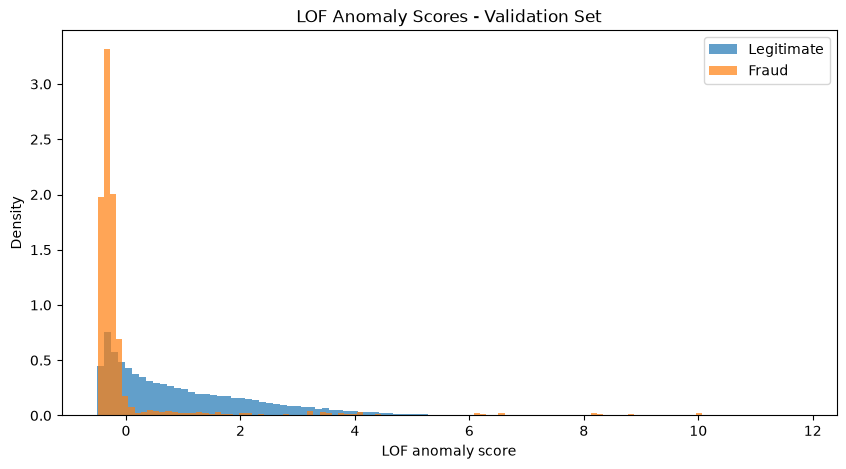

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_scores_lof[y_valid == 0],
    bins=100,
    alpha=0.7,
    density=True,
    label="Legitimate"
)

plt.hist(
    valid_scores_lof[y_valid == 1],
    bins=100,
    alpha=0.7,
    density=True,
    label="Fraud"
)

plt.xlabel("LOF anomaly score")
plt.ylabel("Density")
plt.title("LOF Anomaly Scores - Validation Set")
plt.legend()

plt.show()

10. ROC-AUC et PR-AUC

In [13]:
valid_roc_auc_lof = roc_auc_score(
    y_valid,
    valid_scores_lof
)

valid_pr_auc_lof = average_precision_score(
    y_valid,
    valid_scores_lof
)

print(f"Validation ROC-AUC: {valid_roc_auc_lof:.4f}")
print(f"Validation PR-AUC : {valid_pr_auc_lof:.4f}")

Validation ROC-AUC: 0.1886
Validation PR-AUC : 0.0113


Expérience 2 — LOF uniquement sur les variables numériques

1. Charger les noms des features

In [15]:
import json

MODELS_PATH = Path("../models")

with open(
    MODELS_PATH / "feature_names.json",
    "r",
    encoding="utf-8"
) as f:
    feature_names = json.load(f)

feature_names[:10]

['num__step',
 'num__amount_log',
 'cat__age_0',
 'cat__age_1',
 'cat__age_2',
 'cat__age_3',
 'cat__age_4',
 'cat__age_5',
 'cat__age_6',
 'cat__age_U']

2. Trouver les colonnes numériques

In [16]:
numeric_feature_names = [
    "num__step",
    "num__amount_log"
]

numeric_indices = [
    feature_names.index(name)
    for name in numeric_feature_names
]

numeric_indices

[0, 1]

3. Extraire uniquement ces deux features

In [17]:
X_train_num = X_train[:, numeric_indices].toarray()
X_valid_num = X_valid[:, numeric_indices].toarray()
X_test_num = X_test[:, numeric_indices].toarray()

print("Train :", X_train_num.shape)
print("Valid :", X_valid_num.shape)
print("Test  :", X_test_num.shape)

Train : (374914, 2)
Valid : (108423, 2)
Test  : (111306, 2)


4. Entraîner LOF sur tout le train

In [18]:
lof_numeric = LocalOutlierFactor(
    n_neighbors=35,
    algorithm="kd_tree",
    contamination="auto",
    novelty=True,
    n_jobs=-1
)

In [19]:
import time

start = time.time()

lof_numeric.fit(X_train_num)

training_time_numeric = time.time() - start

print(
    f"Training time: "
    f"{training_time_numeric:.2f} seconds"
)

Training time: 5.90 seconds


5. Calculer les scores

In [20]:
start = time.time()

valid_scores_lof_numeric = (
    -lof_numeric.decision_function(X_valid_num)
)

validation_scoring_time = time.time() - start

print(
    f"Validation scoring time: "
    f"{validation_scoring_time:.2f} seconds"
)

Validation scoring time: 1.10 seconds


In [21]:
test_scores_lof_numeric = (
    -lof_numeric.decision_function(X_test_num)
)

6. Fraude vs normal

In [22]:
numeric_score_analysis = pd.DataFrame({
    "anomaly_score": valid_scores_lof_numeric,
    "fraud": y_valid
})

numeric_score_analysis.groupby(
    "fraud"
)["anomaly_score"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,107223.0,31.631160,25.468450,-0.405815,10.799665,24.797536,48.554979,126.119656
1,1200.0,6.610463,13.017323,-0.433976,0.672327,2.651034,6.159043,121.256295


7. Visualiser

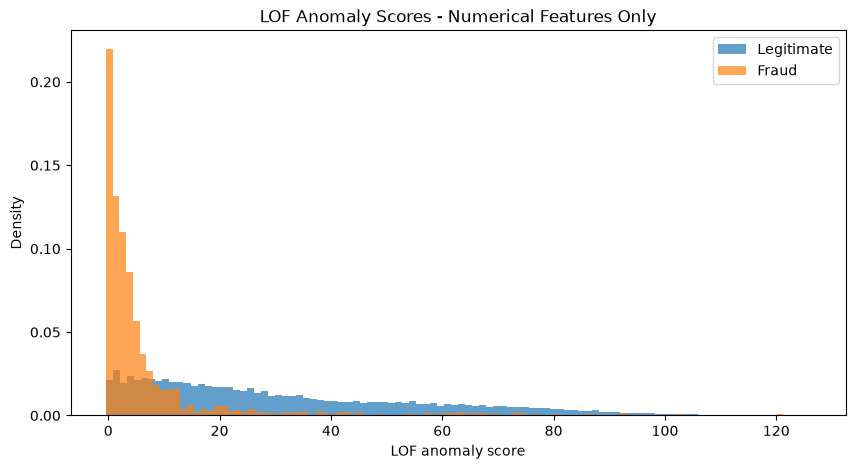

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_scores_lof_numeric[y_valid == 0],
    bins=100,
    alpha=0.7,
    density=True,
    label="Legitimate"
)

plt.hist(
    valid_scores_lof_numeric[y_valid == 1],
    bins=100,
    alpha=0.7,
    density=True,
    label="Fraud"
)

plt.xlabel("LOF anomaly score")
plt.ylabel("Density")
plt.title(
    "LOF Anomaly Scores - Numerical Features Only"
)
plt.legend()

plt.show()

8. ROC-AUC et PR-AUC

In [24]:
roc_numeric = roc_auc_score(
    y_valid,
    valid_scores_lof_numeric
)

pr_numeric = average_precision_score(
    y_valid,
    valid_scores_lof_numeric
)

print(f"Validation ROC-AUC: {roc_numeric:.4f}")
print(f"Validation PR-AUC : {pr_numeric:.4f}")

Validation ROC-AUC: 0.1332
Validation PR-AUC : 0.0060


9. Faisons même une troisième expérience : amount_log seul

In [25]:
amount_index = feature_names.index(
    "num__amount_log"
)

X_train_amount = (
    X_train[:, amount_index].toarray()
)

X_valid_amount = (
    X_valid[:, amount_index].toarray()
)

X_test_amount = (
    X_test[:, amount_index].toarray()
)

In [26]:
print(X_train_amount.shape)

(374914, 1)


In [27]:
lof_amount = LocalOutlierFactor(
    n_neighbors=35,
    algorithm="kd_tree",
    contamination="auto",
    novelty=True,
    n_jobs=-1
)

lof_amount.fit(X_train_amount)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",35
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'kd_tree'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
Name,Type,Value
effective_metric_ effective_metric_: strThe effective metric used for the distance computation.,str,'eu...an'


In [28]:
valid_scores_lof_amount = (
    -lof_amount.decision_function(
        X_valid_amount
    )
)

In [29]:
roc_amount = roc_auc_score(
    y_valid,
    valid_scores_lof_amount
)

pr_amount = average_precision_score(
    y_valid,
    valid_scores_lof_amount
)

print(f"Validation ROC-AUC: {roc_amount:.4f}")
print(f"Validation PR-AUC : {pr_amount:.4f}")

Validation ROC-AUC: 0.6292
Validation PR-AUC : 0.0467


10. Tableau d'ablation

In [30]:
lof_ablation = pd.DataFrame({
    "Experiment": [
        "LOF - All features",
        "LOF - Numerical only",
        "LOF - Amount only"
    ],
    "Features": [
        79,
        2,
        1
    ],
    "ROC-AUC": [
        0.1886,
        roc_numeric,
        roc_amount
    ],
    "PR-AUC": [
        0.0113,
        pr_numeric,
        pr_amount
    ]
})

lof_ablation

,Experiment,Features,ROC-AUC,PR-AUC
0,LOF - All features,79,0.188600,0.011300
1,LOF - Numerical only,2,0.133168,0.005966
2,LOF - Amount only,1,0.629175,0.046713
